# Gradient Boosting Model - Home Credit Default Risk

## 1. Import Libraries


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Data


In [5]:
df = pd.read_csv('../data/application_train.csv')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Shape: (307511, 122)
Rows: 307,511
Columns: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Exploratory Data Analysis
### 3.1 Missing Values
We check how many missing values exist in each column. Columns with very high missing rates 
may need to be dropped, while columns with low missing rates can be imputed with the mean or median.

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(f"Columns with missing values: {len(missing_df)}")
missing_df.head(20)

Columns with missing values: 67


,Missing Count,Missing %
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_MODE,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_AVG,210199,68.35


### 3.2 Target Distribution
We plot the target variable to check for class imbalance. With only 8% defaults, the dataset 
is heavily imbalanced - this is why we use AUC rather than accuracy as our evaluation metric.

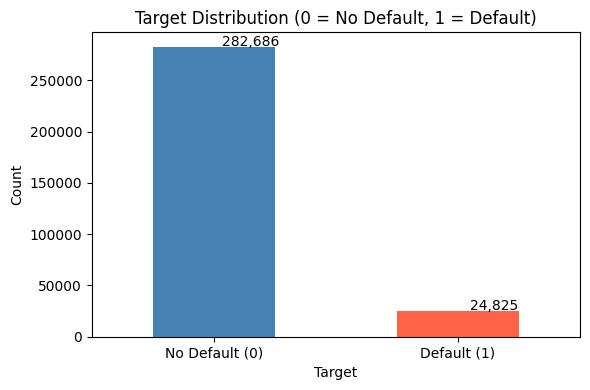


Default rate: 8.07%


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
df['TARGET'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Target Distribution (0 = No Default, 1 = Default)')
ax.set_xlabel('Target')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + 0.4, p.get_height() + 1000), ha='center')

plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=150)
plt.show()

print(f"\nDefault rate: {df['TARGET'].mean()*100:.2f}%")

### 3.3 Correlation Heatmap
We look at how numeric features correlate with the target variable to identify the most predictive features.

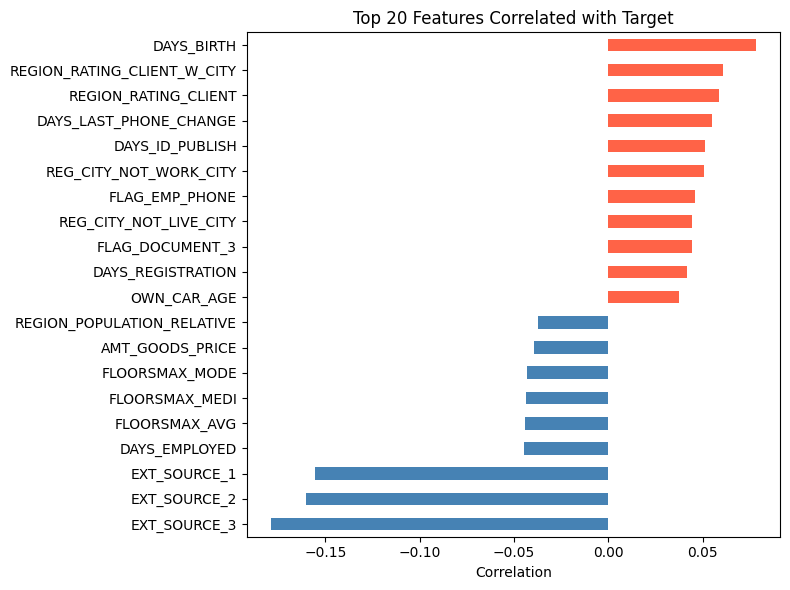

In [8]:
# Select numeric columns and compute correlation with target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

# Plot top 20 most correlated features
top_corr = corr.head(20)

plt.figure(figsize=(8, 6))
top_corr.sort_values().plot(kind='barh', color=['tomato' if x > 0 else 'steelblue' for x in top_corr.sort_values()])
plt.title('Top 20 Features Correlated with Target')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()

## 4. Preprocessing

### 4.1 Handle Outliers
DAYS_EMPLOYED has a known outlier value of 365243 which represents pensioners and should be 
flagged separately rather than treated as a numeric value.

In [9]:
# Flag the outlier as a separate binary feature
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# Replace the outlier with NaN so it gets imputed later
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

print(f"Anomaly flags created: {df['DAYS_EMPLOYED_ANOMALY'].sum():,}")
print(f"DAYS_EMPLOYED missing after fix: {df['DAYS_EMPLOYED'].isnull().sum():,}")

Anomaly flags created: 55,374
DAYS_EMPLOYED missing after fix: 55,374


### 4.2 Encode Categorical Variables
We convert categorical text columns into numbers using Label Encoding so the model can process them.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Encoded {len(cat_cols)} categorical columns")
print(cat_cols)

Encoded 16 categorical columns
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


### 4.3 Define Features and Target

In [11]:
# Drop ID column, separate target
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (307511, 121)
Target shape: (307511,)


## 5. Baseline Model

### 5.1 Train/Validation Split
We split the data into 80% training and 20% validation to evaluate model performance on unseen data.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Validation size: {X_val.shape[0]:,}")

Train size: 246,008
Validation size: 61,503


### 5.2 Logistic Regression Baseline
A simple linear model used as a baseline to compare against gradient boosting models.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# Logistic regression cannot handle missing values so we impute first
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_imp, y_train)

lr_preds = lr.predict_proba(X_val_imp)[:, 1]
lr_auc = roc_auc_score(y_val, lr_preds)
print(f"Logistic Regression AUC: {lr_auc:.4f}")

Logistic Regression AUC: 0.6322


### 5.3 LightGBM Baseline
LightGBM handles missing values natively and is much more powerful than logistic regression.

In [14]:
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

lgb_preds = lgb_model.predict_proba(X_val)[:, 1]
lgb_auc = roc_auc_score(y_val, lgb_preds)
print(f"LightGBM Baseline AUC: {lgb_auc:.4f}")

LightGBM Baseline AUC: 0.7574


### 5.4 ROC Curve & Confusion Matrix

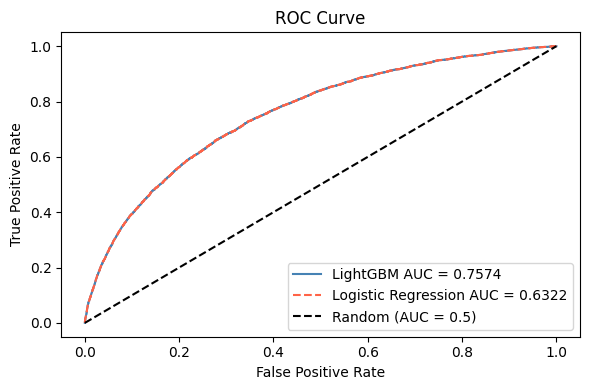

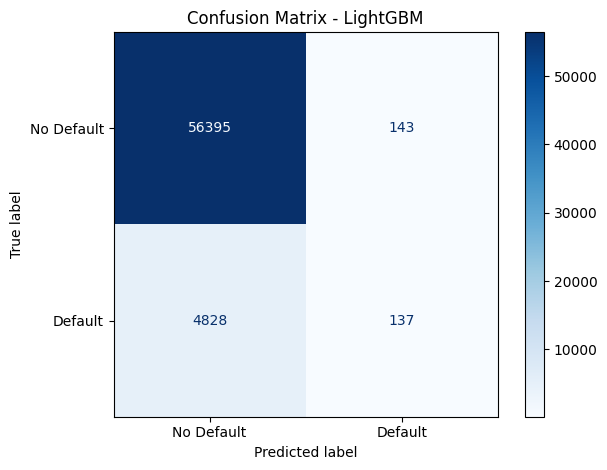

In [15]:
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, lgb_preds)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='steelblue', label=f'LightGBM AUC = {lgb_auc:.4f}')
plt.plot(fpr, tpr, color='tomato', linestyle='--', label=f'Logistic Regression AUC = {lr_auc:.4f}')
plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png', dpi=150)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_val, (lgb_preds >= 0.5).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()

## 6. Cross Validation
We use Stratified K-Fold cross validation with 5 folds to get a more reliable estimate of model 
performance. This ensures each fold maintains the same 8% default rate as the full dataset.

In [16]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
    model.fit(X_fold_train, y_fold_train)

    preds = model.predict_proba(X_fold_val)[:, 1]
    auc = roc_auc_score(y_fold_val, preds)
    cv_scores.append(auc)
    print(f"Fold {fold+1} AUC: {auc:.4f}")

print(f"\nMean CV AUC: {np.mean(cv_scores):.4f}")
print(f"Std CV AUC:  {np.std(cv_scores):.4f}")

Fold 1 AUC: 0.7510
Fold 2 AUC: 0.7573
Fold 3 AUC: 0.7509
Fold 4 AUC: 0.7581
Fold 5 AUC: 0.7509

Mean CV AUC: 0.7536
Std CV AUC:  0.0033


## 7. Feature Engineering
We create new features from existing ones to give the model more predictive signal.
Ratio features are particularly useful as they capture relationships between variables
that the model might not pick up on its own.

In [ ]:
def create_features(df):
    # Credit to income ratio - how much credit relative to income
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

    # Annuity to income ratio - how much of income goes to repayments
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

    # Credit to annuity ratio - loan term proxy
    df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']

    # Goods price to credit ratio - how much of loan covers goods
    df['GOODS_CREDIT_RATIO'] = df['AMT_GOODS_PRICE'] / df['AMT_CREDIT']

    # Age in years (DAYS_BIRTH is negative)
    df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365

    # Years employed
    df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365

    # Employment to age ratio - how long they've been working relative to age
    df['EMPLOYED_TO_AGE_RATIO'] = df['YEARS_EMPLOYED'] / df['AGE_YEARS']

    # EXT_SOURCE mean and std - summary of external credit scores
    df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCE_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
    df['EXT_SOURCE_MIN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)

    return df

df = create_features(df)

# Redefine X with new features
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

print(f"New features shape: {X.shape}")

New features shape: (307511, 131)


In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgb_model2 = lgb.LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
lgb_model2.fit(X_train, y_train)

lgb_preds2 = lgb_model2.predict_proba(X_val)[:, 1]
lgb_auc2 = roc_auc_score(y_val, lgb_preds2)
print(f"LightGBM AUC after feature engineering: {lgb_auc2:.4f}")
print(f"Improvement: {lgb_auc2 - lgb_auc:.4f}")

LightGBM AUC after feature engineering: 0.7646
Improvement: 0.0072


## 8. Hyperparameter Tuning
We use Optuna to automatically search for the best LightGBM hyperparameters.
Instead of manually trying different settings, Optuna intelligently explores the parameter 
space to find the combination that maximises AUC.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'verbose': -1
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_t, y_t)
        preds = model.predict_proba(X_v)[:, 1]
        scores.append(roc_auc_score(y_v, preds))

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nBest AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]


Best AUC: 0.7658
Best params: {'n_estimators': 734, 'learning_rate': 0.04755691022323291, 'num_leaves': 31, 'max_depth': 4, 'min_child_samples': 100, 'subsample': 0.6506197403598637, 'colsample_bytree': 0.6521779764173031, 'reg_alpha': 0.9029858641150829, 'reg_lambda': 0.9947465786571784}


### 8.1 Train Final Model with Best Parameters

In [20]:
best_params = study.best_params
best_params['random_state'] = 42
best_params['verbose'] = -1

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

final_preds = final_model.predict_proba(X_val)[:, 1]
final_auc = roc_auc_score(y_val, final_preds)
print(f"Final Model AUC: {final_auc:.4f}")

Final Model AUC: 0.7718


## 9. Model Comparison
We compare all models on the same validation set to see which performs best.

In [21]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

results = {}

# Already have these
results['Logistic Regression'] = lr_auc
results['LightGBM Baseline'] = lgb_auc
results['LightGBM Tuned'] = final_auc

# Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_imp, y_train)
results['Random Forest'] = roc_auc_score(y_val, rf.predict_proba(X_val_imp)[:, 1])
print(f"Random Forest AUC: {results['Random Forest']:.4f}")

# XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=500, random_state=42, verbosity=0, eval_metric='auc')
xgb.fit(X_train, y_train)
results['XGBoost'] = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])
print(f"XGBoost AUC: {results['XGBoost']:.4f}")

# CatBoost
print("Training CatBoost...")
cb = CatBoostClassifier(n_estimators=500, random_state=42, verbose=0)
cb.fit(X_train, y_train)
results['CatBoost'] = roc_auc_score(y_val, cb.predict_proba(X_val)[:, 1])
print(f"CatBoost AUC: {results['CatBoost']:.4f}")

Training Random Forest...
Random Forest AUC: 0.7208
Training XGBoost...
XGBoost AUC: 0.7373
Training CatBoost...
CatBoost AUC: 0.7657


### 9.1 Model Comparison Table

                          AUC
LightGBM Tuned       0.771751
CatBoost             0.765713
LightGBM Baseline    0.757425
XGBoost              0.737261
Random Forest        0.720811
Logistic Regression  0.632237


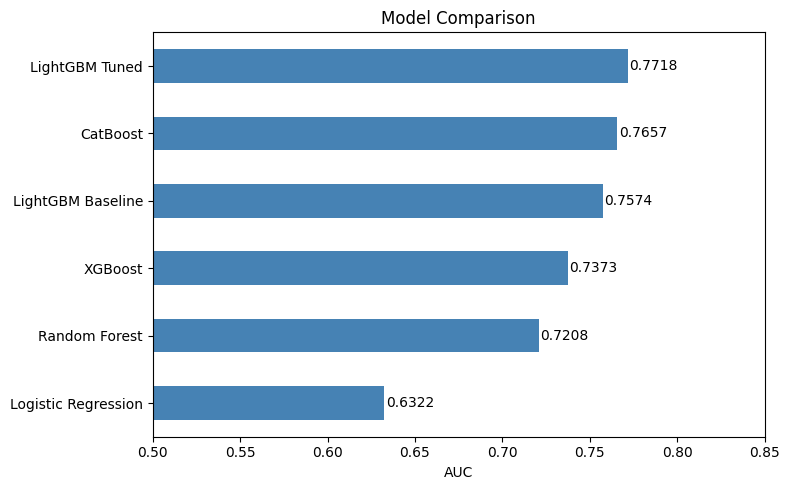

In [22]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['AUC'])
results_df = results_df.sort_values('AUC', ascending=False)

print(results_df.to_string())

# Plot
plt.figure(figsize=(8, 5))
results_df['AUC'].sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('AUC')
plt.title('Model Comparison')
plt.xlim(0.5, 0.85)
for i, v in enumerate(results_df['AUC'].sort_values()):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150)
plt.show()

## 10. Model Interpretation

### 10.1 Feature Importance
We look at which features the model relied on most when making predictions.

<Figure size 800x600 with 0 Axes>

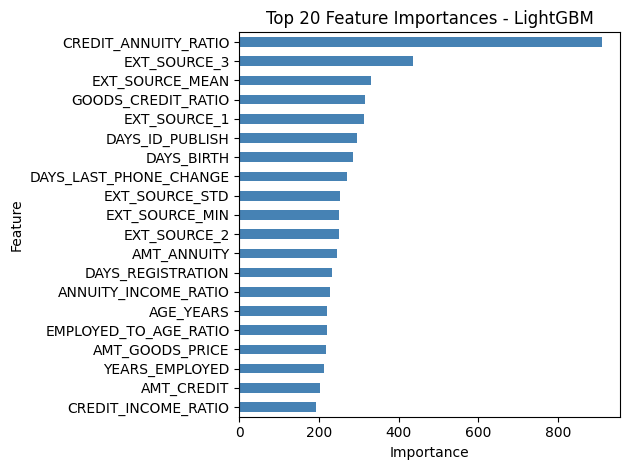

In [23]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(8, 6))
importance_df.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance', color='steelblue', legend=False
)
plt.title('Top 20 Feature Importances - LightGBM')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

### 10.2 SHAP Values
SHAP explains how much each feature pushed each individual prediction higher or lower.
Unlike feature importance, SHAP shows the direction of each feature's effect.

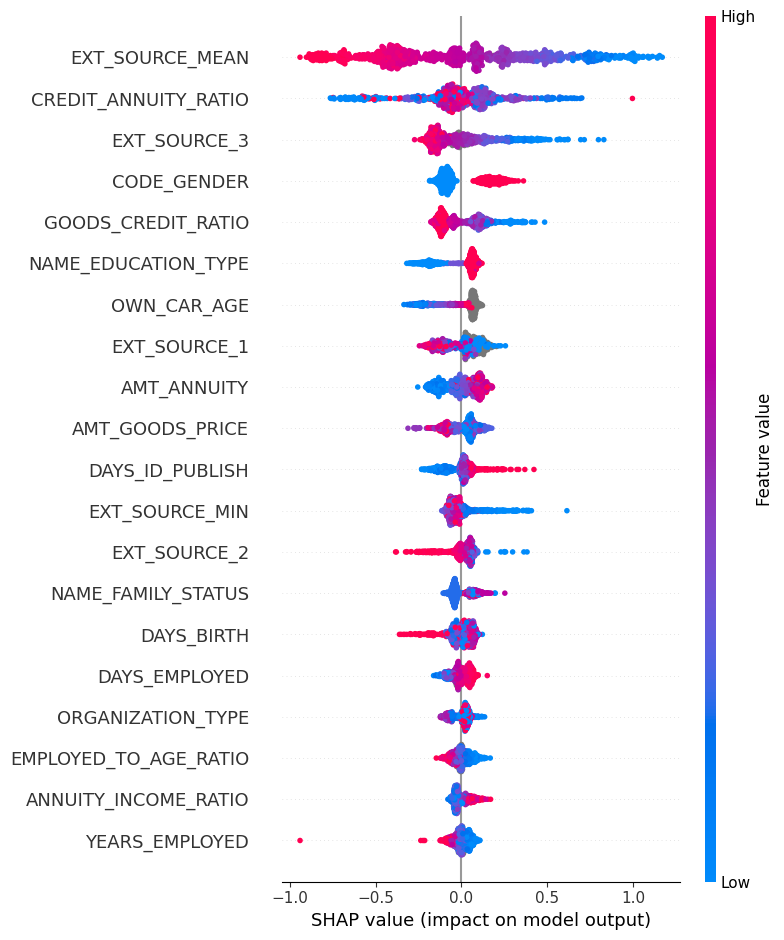

In [24]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val.iloc[:1000])

plt.figure()
shap.summary_plot(shap_values, X_val.iloc[:1000], show=False)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.3 Precision-Recall Curve
The precision-recall curve is useful for imbalanced datasets as it focuses specifically 
on the model's performance on the minority class (defaulters).

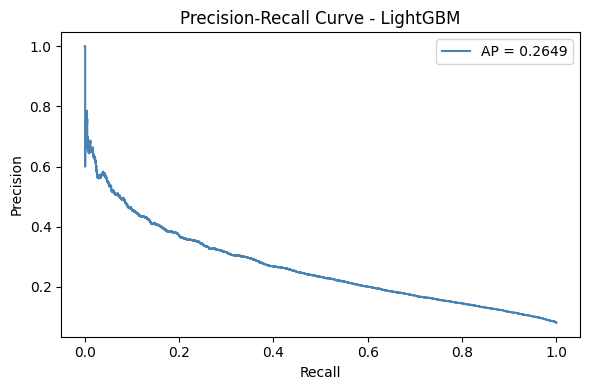

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, final_preds)
ap = average_precision_score(y_val, final_preds)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='steelblue', label=f'AP = {ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - LightGBM')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/precision_recall_curve.png', dpi=150)
plt.show()

## 11. Conclusion

This project built a supervised machine learning pipeline to predict loan default risk
using the Home Credit dataset.

The most predictive features were EXT_SOURCE_1/2/3 (external credit scores), along with 
CREDIT_ANNUITY_RATIO (an engineered feature) and DAYS_BIRTH. This makes intuitive sense - 
creditworthiness scores and how much of income goes to repayments are natural indicators 
of default risk.

LightGBM (AUC 0.7718) significantly outperformed Logistic Regression (AUC 0.6322). The large 
gap confirms that the relationship between features and default risk is highly non-linear, 
which tree-based models capture much better than linear models. The model also proved stable 
across validation folds, with CV AUC scores ranging from 0.7509 to 0.7581 and a standard 
deviation of only 0.0033, indicating it generalises well and is not overfitting.

With only 8% defaults, class imbalance is a key challenge. Using the default threshold of 0.5 
causes the model to predict almost everyone as non-default - as seen in the confusion matrix 
where only 137 out of 4,965 actual defaults were caught. In practice the threshold should be 
lowered to increase recall, depending on the business cost of missing a real defaulter versus 
flagging a good customer. The model struggles most with actual defaulters who have incomplete 
EXT_SOURCE scores and average credit metrics, making them hard to distinguish from non-defaulters.

Regarding data quality, DAYS_EMPLOYED contained a suspicious outlier value of 365243 for 
pensioners which was flagged and replaced with NaN to avoid leakage. Generally, variables 
filled in after the loan decision should be treated with caution. Finally, this project used 
only application_train.csv and achieved AUC of 0.7718. Merging auxiliary tables such as 
bureau.csv and previous_application.csv would likely push AUC above 0.78-0.80 by adding 
repayment history features.